## Importación de librerías y carga del perfil del estudiante

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
%matplotlib inline

df_info = pd.read_csv('./../../dataset/oulad/studentInfo.csv')

print(f"Total de registros iniciales en studentInfo: {len(df_info)}")

Total de registros iniciales en studentInfo: 32593


## Redefinición de la variable objetivo y visualización

C:\Users\joseb\AppData\Local\Temp\ipykernel_8704\4091422091.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_info_clean, palette=['#2ECC71', '#E74C3C'])


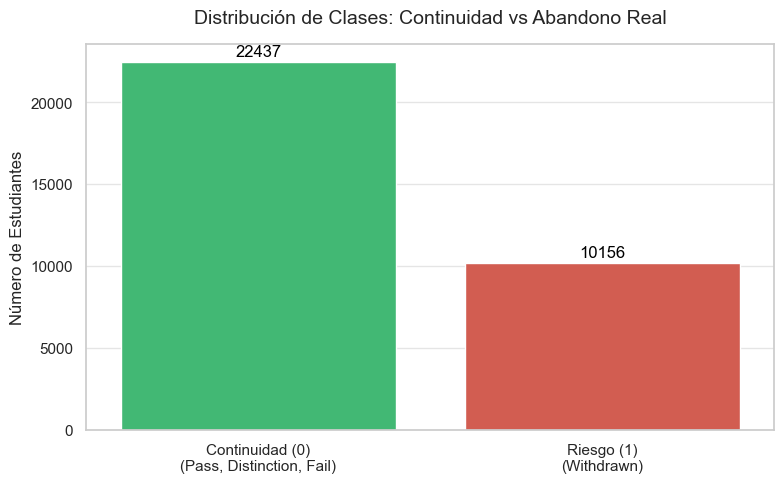

Porcentaje de Riesgo (Abandono): 31.16%
Porcentaje de Continuidad: 68.84%


In [3]:
df_info['target'] = df_info['final_result'].map({
    'Withdrawn': 1,
    'Fail': 0,
    'Pass': 0,
    'Distinction': 0
})

cols_to_drop = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
df_info_clean = df_info.drop(columns=cols_to_drop)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='target', data=df_info_clean, palette=['#2ECC71', '#E74C3C'])

plt.title('Distribución de Clases: Continuidad vs Abandono Real', fontsize=14, pad=15)
plt.xticks(ticks=[0, 1], labels=['Continuidad (0)\n(Pass, Distinction, Fail)', 'Riesgo (1)\n(Withdrawn)'])
plt.ylabel('Número de Estudiantes')
plt.xlabel('')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

total = len(df_info_clean)
riesgo = df_info_clean['target'].sum()
print(f"Porcentaje de Riesgo (Abandono): {(riesgo/total)*100:.2f}%")
print(f"Porcentaje de Continuidad: {((total-riesgo)/total)*100:.2f}%")

# Extracción de la huella digital a 90 días (Comportamiento y Notas)

In [8]:
print("Cargando y procesando interacciones (puede tardar unos segundos)...")
df_vle = pd.read_csv('./../../dataset/oulad/studentVle.csv')
df_assess = pd.read_csv('./../../dataset/oulad/studentAssessment.csv')

df_vle_90 = df_vle[df_vle['date'] <= 90].copy()

df_vle_90['week'] = (df_vle_90['date'] // 7) + 1
vle_weekly = df_vle_90.pivot_table(
    index=['id_student', 'code_module', 'code_presentation'],
    columns='week',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
).reset_index()

vle_weekly.columns = [f'clicks_w{c}' if isinstance(c, (int, float)) else c for c in vle_weekly.columns]

df_assess_90 = df_assess[df_assess['date_submitted'] <= 90].copy()

df_assess_90['score'] = pd.to_numeric(df_assess_90['score'], errors='coerce')

assess_summary = df_assess_90.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    total_assessments=('id_assessment', 'count')
).reset_index()

print("Procesamiento completado.")

Cargando y procesando interacciones (puede tardar unos segundos)...
Procesamiento completado.


# Consolidación de la matriz de características

In [9]:
master_df = pd.merge(df_info_clean, vle_weekly, on=['id_student', 'code_module', 'code_presentation'], how='left')

master_df = pd.merge(master_df, assess_summary, on='id_student', how='left')

master_df.fillna(0, inplace=True)

print(f"Dimensiones de la matriz lista para entrenar: {master_df.shape}")
master_df.head()

Dimensiones de la matriz lista para entrenar: (32593, 26)


,code_module,code_presentation,id_student,num_of_prev_attempts,studied_credits,final_result,target,clicks_w-3,clicks_w-2,clicks_w-1,...,clicks_w6,clicks_w7,clicks_w8,clicks_w9,clicks_w10,clicks_w11,clicks_w12,clicks_w13,avg_score,total_assessments
0,AAA,2013J,11391,0,240,Pass,0,0.0,0.0,0.0,...,60.0,22.0,20.0,0.0,16.0,9.0,31.0,2.0,81.5,2.0
1,AAA,2013J,28400,0,60,Pass,0,0.0,0.0,79.0,...,0.0,21.0,23.0,31.0,25.0,27.0,10.0,59.0,69.0,2.0
2,AAA,2013J,30268,0,60,Withdrawn,1,0.0,0.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AAA,2013J,31604,0,60,Pass,0,0.0,0.0,129.0,...,119.0,53.0,66.0,12.0,119.0,18.0,0.0,39.0,71.5,2.0
4,AAA,2013J,32885,0,60,Pass,0,0.0,0.0,97.0,...,16.0,0.0,0.0,4.0,3.0,18.0,50.0,8.0,49.5,2.0


# Entrenamiento del modelo Random Forest

In [10]:
columnas_a_ignorar = ['id_student', 'code_module', 'code_presentation', 'final_result', 'target']
X = master_df.drop(columns=[col for col in columnas_a_ignorar if col in master_df.columns])
y = master_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Estudiantes en entrenamiento: {len(X_train)}")
print(f"Estudiantes en prueba: {len(X_test)}")

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)
y_pred = modelo_rf.predict(X_test)

print("\n¡Entrenamiento finalizado!")

Estudiantes en entrenamiento: 26074
Estudiantes en prueba: 6519

¡Entrenamiento finalizado!


# Evaluación del rendimiento


--- REPORTE DETALLADO DE CLASIFICACIÓN ---
                 precision    recall  f1-score   support

Continuidad (0)       0.85      0.93      0.89      4488
   Abandono (1)       0.80      0.63      0.71      2031

       accuracy                           0.84      6519
      macro avg       0.83      0.78      0.80      6519
   weighted avg       0.83      0.84      0.83      6519



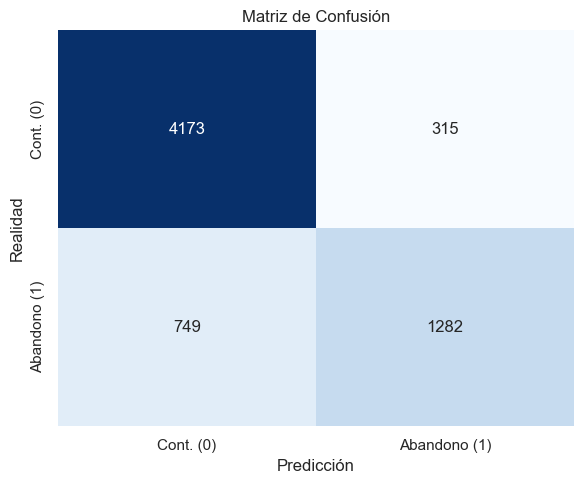

C:\Users\joseb\AppData\Local\Temp\ipykernel_8704\4231959710.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=metricas_acc_prec, y=valores_acc_prec, palette=['#3498DB', '#9B59B6'])


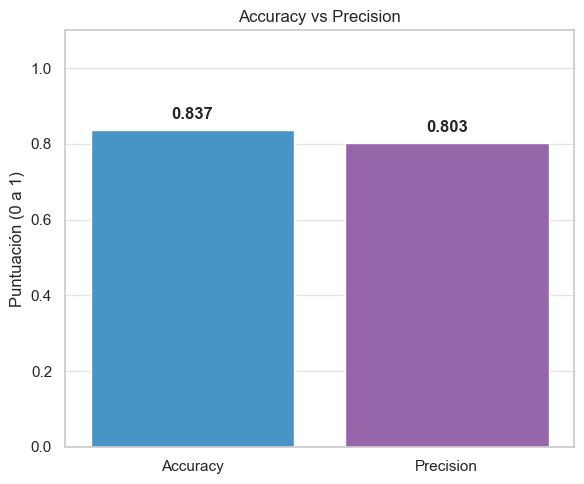

C:\Users\joseb\AppData\Local\Temp\ipykernel_8704\4231959710.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=metricas_todas, y=valores_todos, palette='viridis')


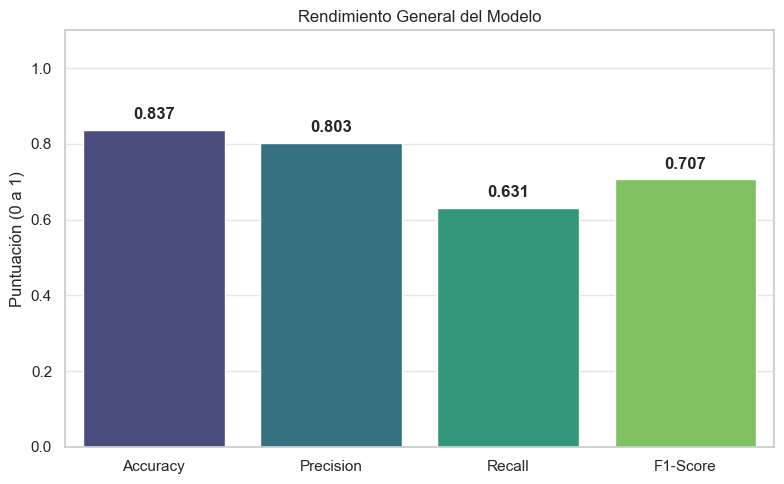

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n--- REPORTE DETALLADO DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Continuidad (0)', 'Abandono (1)']))


plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cont. (0)', 'Abandono (1)'],
            yticklabels=['Cont. (0)', 'Abandono (1)'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
metricas_acc_prec = ['Accuracy', 'Precision']
valores_acc_prec = [acc, prec]

ax1 = sns.barplot(x=metricas_acc_prec, y=valores_acc_prec, palette=['#3498DB', '#9B59B6'])
plt.title('Accuracy vs Precision')
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0 a 1)')

for i, v in enumerate(valores_acc_prec):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
metricas_todas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores_todos = [acc, prec, rec, f1]

ax2 = sns.barplot(x=metricas_todas, y=valores_todos, palette='viridis')
plt.title('Rendimiento General del Modelo')
plt.ylim(0, 1.1)
plt.ylabel('Puntuación (0 a 1)')

for i, v in enumerate(valores_todos):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()